# Large-scale multinomial mixture example

This notebook demonstrates the public `densmix` API for multinomial mixtures:

- `simulate_multinomial()` generates data and returns a
  `MultinomialSimulation`;
- `fit_multinomial()` fits the model and returns a `MultinomialFit`.

The returned objects expose named attributes instead of unstructured dictionary
keys. Simulation results provide `.data`, `.labels`, `.mixture_profiles`, and
`.parameters`. Fit results provide `.weights`, `.mixture_profiles`,
`.responsibilities`, `.converged`, and `.n_iter`.

## Experiment design

We generate 100 datasets with three components and true component weights
$(0.1, 0.2, 0.7)$. Each dataset has 1,000 rows and 12 buckets (columns).

For each generated dataset:

1. A probability profile for every component is drawn from a uniform Dirichlet
   distribution.
2. The number of rows assigned to each component is drawn using the component
   weights.
3. One total action count is drawn for each component from a binomial
   distribution with `max_actions` trials and success probability
   `prob_action`.
4. Rows belonging to that component are drawn from its multinomial profile.

With `max_actions=100` and `prob_action=0.5`, the expected total count per row
is 50.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import linear_sum_assignment

from densmix import fit_multinomial, simulate_multinomial

## Generate the datasets

`simulate_multinomial()` returns the generated matrix, true component labels,
true mixture profiles, and the parameters used by the generator.

In [2]:
np.random.seed(1234)

n_sim = 100
sample_size = 1_000

multinomial_parameters = {
    "n_components": 3,
    "n_buckets": 12,
    "dirichlet": np.ones(12),
    "component_weights": np.array([0.1, 0.2, 0.7]),
    "n_actions_per_bucket": {
        "max_actions": 100,
        "prob_action": 0.5,
    },
}

multinomial_simulations = [
    simulate_multinomial(
        size=sample_size,
        parameters=multinomial_parameters,
    )
    for _ in range(n_sim)
]

example_simulation = multinomial_simulations[0]

print(f"Generated {len(multinomial_simulations)} datasets.")
print(f"First data matrix shape: {example_simulation.data.shape}")
print(f"First label vector shape: {example_simulation.labels.shape}")
print(f"First profile matrix shape: {example_simulation.mixture_profiles.shape}")

Generated 100 datasets.
First data matrix shape: (1000, 12)
First label vector shape: (1000,)
First profile matrix shape: (12, 3)


## Fit the mixtures

Pass each simulation's `.data` matrix to `fit_multinomial()`. The number of
components is explicit in the public function call.

In [3]:
n_components = multinomial_parameters["n_components"]

multinomial_fits = [
    fit_multinomial(
        simulation.data,
        n_components=n_components,
    )
    for simulation in multinomial_simulations
]

fit_summary_df = pd.DataFrame(
    {
        "converged": [fit.converged for fit in multinomial_fits],
        "n_iter": [fit.n_iter for fit in multinomial_fits],
        "profiles_delta": [fit.profiles_delta for fit in multinomial_fits],
    }
)

fit_summary_df.head()

,converged,n_iter,profiles_delta
0,True,5,9.863791e-08
1,True,7,6.248687e-07
2,True,5,1.274141e-07
3,True,805,3.925841e-07
4,True,39,9.221711e-07


## Align fitted and true component labels

The numerical component labels returned by a mixture model are arbitrary. For
example, true component 0 might be represented by fitted component 2 without
changing the model.

For each fit, we therefore:

1. obtain predicted labels with `argmax` over `.responsibilities`;
2. build a true-by-fitted confusion matrix;
3. use the Hungarian algorithm to find the permutation with the largest number
   of matched rows;
4. reorder fitted weights and profiles into true-component order.

In [5]:
def evaluate_aligned_fit(simulation, fit):
    fitted_labels = np.argmax(fit.responsibilities, axis=1)
    true_labels = simulation.labels
    n_components = fit.responsibilities.shape[1]

    confusion_matrix = np.zeros(
        (n_components, n_components),
        dtype=int,
    )
    np.add.at(
        confusion_matrix,
        (true_labels, fitted_labels),
        1,
    )

    true_component_indices, fitted_component_indices = linear_sum_assignment(
        confusion_matrix,
        maximize=True,
    )

    matched_rows = confusion_matrix[
        true_component_indices,
        fitted_component_indices,
    ].sum()
    accuracy = matched_rows / confusion_matrix.sum()

    aligned_weights = np.empty(n_components)
    aligned_weights[true_component_indices] = fit.weights[
        fitted_component_indices
    ]

    aligned_profiles = np.empty_like(fit.mixture_profiles)
    aligned_profiles[:, true_component_indices] = fit.mixture_profiles[
        :,
        fitted_component_indices,
    ]

    return {
        "accuracy": accuracy,
        "weights": aligned_weights,
        "mixture_profiles": aligned_profiles,
        "confusion_matrix": confusion_matrix,
    }


alignment_results = [
    evaluate_aligned_fit(simulation, fit)
    for simulation, fit in zip(multinomial_simulations, multinomial_fits)
]

accuracies = np.array([
    result["accuracy"]
    for result in alignment_results
])

## Label accuracy

The histogram summarizes classification accuracy after label alignment. This is
an intentionally easy case: it has only three components and around 50 counts
per row on average.

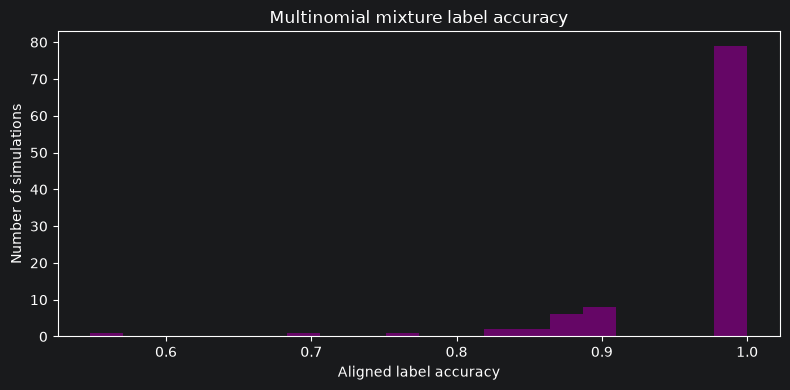

Mean accuracy: 96.8%
Median accuracy: 100.0%
Perfectly classified datasets: 67.0%


In [6]:
plt.figure(figsize=(8, 4))
plt.hist(accuracies, bins=20, color="purple", alpha=0.75)
plt.xlabel("Aligned label accuracy")
plt.ylabel("Number of simulations")
plt.title("Multinomial mixture label accuracy")
plt.tight_layout()
plt.show()

print(f"Mean accuracy: {accuracies.mean():.1%}")
print(f"Median accuracy: {np.median(accuracies):.1%}")
print(f"Perfectly classified datasets: {np.mean(accuracies == 1):.1%}")

## Component weights

After label alignment, compare estimated component weights with the true values
$(0.1, 0.2, 0.7)$. The dashed line in each panel is the corresponding true
weight.

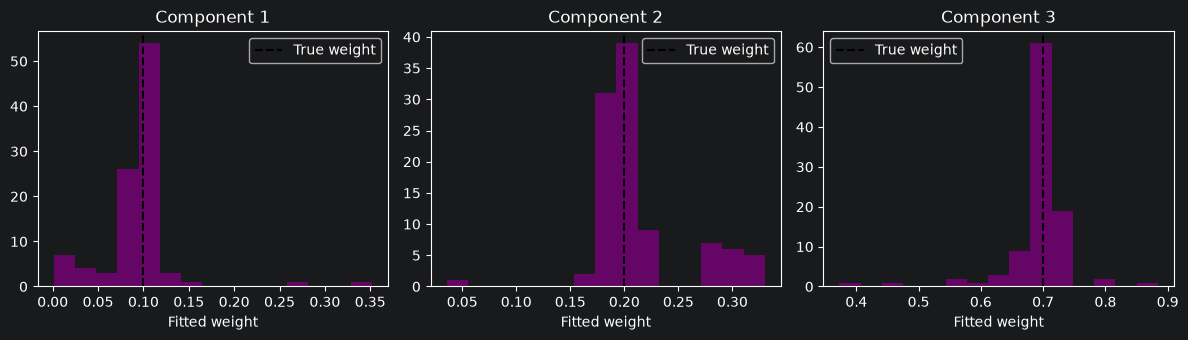

In [7]:
aligned_weights = np.vstack([
    result["weights"]
    for result in alignment_results
])
true_weights = multinomial_parameters["component_weights"]

fig, axes = plt.subplots(1, n_components, figsize=(12, 3.5))

for component_index, ax in enumerate(axes):
    ax.hist(
        aligned_weights[:, component_index],
        bins=15,
        color="purple",
        alpha=0.75,
    )
    ax.axvline(
        true_weights[component_index],
        color="black",
        linestyle="--",
        label="True weight",
    )
    ax.set_title(f"Component {component_index + 1}")
    ax.set_xlabel("Fitted weight")
    ax.legend()

plt.tight_layout()
plt.show()

# Mixture profiles

The simulation and fit objects both expose `.mixture_profiles`. The following
plots compare the true and aligned fitted bucket probabilities for the first
dataset.

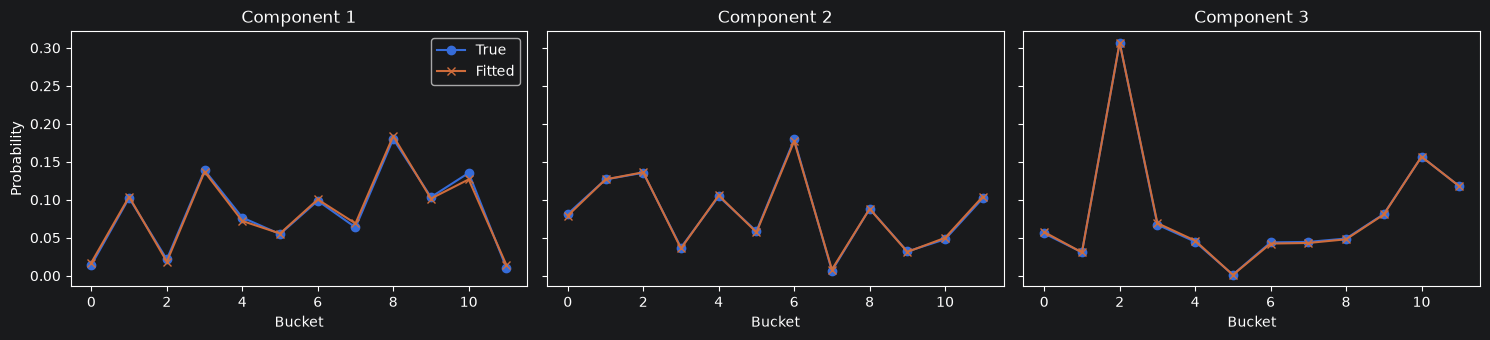

In [8]:
example_result = alignment_results[0]
true_profiles = example_simulation.mixture_profiles
fitted_profiles = example_result["mixture_profiles"]
bucket_indices = np.arange(true_profiles.shape[0])

fig, axes = plt.subplots(1, n_components, figsize=(15, 3.5), sharey=True)

for component_index, ax in enumerate(axes):
    ax.plot(
        bucket_indices,
        true_profiles[:, component_index],
        marker="o",
        label="True",
    )
    ax.plot(
        bucket_indices,
        fitted_profiles[:, component_index],
        marker="x",
        label="Fitted",
    )
    ax.set_title(f"Component {component_index + 1}")
    ax.set_xlabel("Bucket")

axes[0].set_ylabel("Probability")
axes[0].legend()
plt.tight_layout()
plt.show()

## Convergence diagnostics

Use `.n_iter` and `.converged` directly from each `MultinomialFit` object.

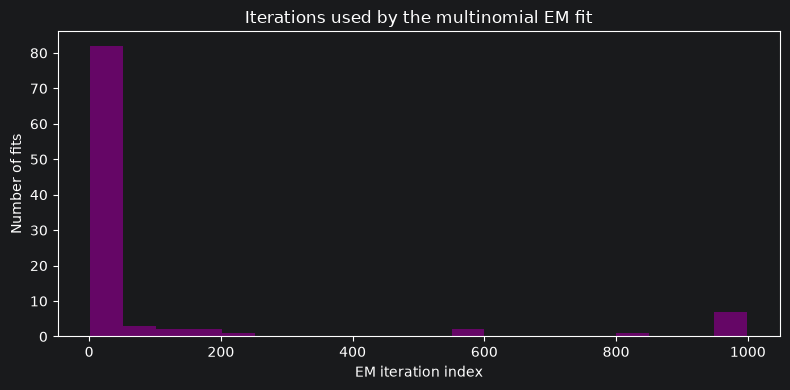

Converged fits: 94.0%


minimum      2.0
25%          4.0
median       5.0
75%         12.5
maximum    999.0
Name: n_iter, dtype: float64

In [9]:
iteration_counts = np.array([fit.n_iter for fit in multinomial_fits])
convergence_flags = np.array([fit.converged for fit in multinomial_fits])

plt.figure(figsize=(8, 4))
plt.hist(iteration_counts, bins=20, color="purple", alpha=0.75)
plt.title("Iterations used by the multinomial EM fit")
plt.xlabel("EM iteration index")
plt.ylabel("Number of fits")
plt.tight_layout()
plt.show()

iteration_quantiles = pd.Series(
    np.quantile(iteration_counts, [0, 0.25, 0.5, 0.75, 1]),
    index=["minimum", "25%", "median", "75%", "maximum"],
    name="n_iter",
)

print(f"Converged fits: {convergence_flags.mean():.1%}")
iteration_quantiles

The public functions keep model construction concise, while structured result
objects make generated labels and profiles, fitted responsibilities and weights,
and convergence diagnostics available through stable, named attributes.